# PARTICIPANT 3

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

**Key features:**
- Ingest and preprocess environmental data from multiple sources.
- Calibrate and baseline CO2 and noise data.
- Handle missing, infinite, and erroneous data points.
- Generate dictionaries categorizing data by room and type for analysis.

**Notes about campaign:**
1. Grafana - issue 17/05/2021 - outdoor unit put outside - this is after start of DF. This was after having some issues. The missing data is nans, so hopefully shouldnt cause any issues.
2. Equipment uninstalled 03/09/2021. Fine - reflected in code.
3. Grafana - 21/04/2021 high CO2.
4. Noise seems to start on 07/04/2021 - this is after start of DF
5. General notes - issues with outdoor unit power. See point 1 above.
6. 12197 - Issues with outdoor unit. indoor and outdoor unit swapped at beginning. Outdoor unit - nans and brought inside. Fine - this is filtered out.
7. Issue with outdoor unit resolved 15/05/2021

## Import Packages and Functions

In [1]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system.

**Sensor IDs:**
- 34646: Kitchen/living (AQ110A EI130961 T-34646)
- 34645: Outside (AQ110A EI130962 T-34645)
- 35992: Bedroom 1 (GD47AC EI130986 T-35992)
- 36243: Bedroom 2 (GD47AC EI130992 T-36243)

In [2]:
p3_eltek = ingest_aq110a(path = '../data/p3_north_west_london_flat/data_unprocessed/K01830-12197-06092021093912.csv'
                     , import_variables = ['', 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'temperature', 'humidity', 'co2', 'temperature', 'humidity', 'co2']
                     , column_names = ['living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc'
                                       ,'external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc'
                                       , 'bedroom1_temperature', 'bedroom1_humidity', 'bedroom1_co2'
                                       , 'bedroom2_temperature', 'bedroom2_humidity', 'bedroom2_co2'
                                       ]
                     , convert_no2 = True
                     , convert_co = True
                     , input_interpolate = True
                     , input_iterpolate_limit = 6
                     )

# delete external temp and rh
del p3_eltek['external_temperature']
del p3_eltek['external_humidity']
# issue with power to outdoor unit for a few periods
"""
ignore between 2021-02-13 12:00:00 and 2021-02-19 12:00:00
ignore between 2021-05-02 12:00 and 2021-05-15 00:00:00
"""
for col in p3_eltek:
    if 'external' in col:
        # print(col)
        p3_eltek.loc['2021-02-13 12:00:00':'2021-02-19 12:00:00', col] = np.nan
        p3_eltek.loc['2021-05-02 12:00:00':'2021-05-17 00:00:00', col] = np.nan

# baseline co1 and no2
aq110a_no2_co1_baseline (input_dataframe = p3_eltek
                             , input_percentile = 5)


---------------------------------------------
Ingesting AQ110a data from ../data/p3_north_west_london_flat/data_unprocessed/K01830-12197-06092021093912.csv


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94537/1228987109.py:59: DtypeWarning: Columns (1,2,3,9,10,11,12,13,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  eltek = pd.read_csv(path, skiprows = 3) # ingest



Correction

-----------------------
34646_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_100um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_airflow
baseline_correction

False


## Load Bathroom Data

Load bathroom temperature, humidity, and light data from multiple U12-012 sensors.

**Sensors:**
- First: EI130500 (1080667)
- Second: EI130512 (1089316)
- Third: EI130469 (1088070)

In [3]:
#### bathroom - file 1
p3_bathroom_ieq_1 = ingest_u12_012('../data/p3_north_west_london_flat/data_unprocessed/210312_EI130500.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130500'
                      )

#### bathroom - file 2
p3_bathroom_ieq_2 = ingest_u12_012('../data/p3_north_west_london_flat/data_unprocessed/210604_EI130512.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130512'
                      )

#### bathroom - file 3
p3_bathroom_ieq_3 = ingest_u12_012('../data/p3_north_west_london_flat/data_unprocessed/210903_EI130469.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130469'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p3_north_west_london_flat/data_unprocessed/210312_EI130500.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom_temperature    0
bathroom_humidity       0
bathroom_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p3_north_west_london_flat/data_unprocessed/210604_EI130512.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom_temperature    0
bathroom_humidity       0
bathro

## Join Bathroom Data

Concatenate bathroom data from different time periods:
- File 1: beginning to 2021-03-08 18:00
- File 2: 2021-03-08 18:05 to 2021-05-26 18:00
- File 3: 2021-05-26 18:05 to end

In [4]:
#### join all bathroom 1
p3_bathroom_ieq_1 = p3_bathroom_ieq_1.loc[:'2021-03-08 18:00:00']
p3_bathroom_ieq_2 = p3_bathroom_ieq_2.loc['2021-03-08 18:05:00':'2021-05-26 18:00:00']
p3_bathroom_ieq_3 = p3_bathroom_ieq_3.loc['2021-05-26 18:05:00':]
p3_dfs = [p3_bathroom_ieq_1, p3_bathroom_ieq_2, p3_bathroom_ieq_3]
p3_bathroom = pd.concat(p3_dfs)
p3_bathroom = p3_bathroom.resample('5min').ffill() # resample and backfill for 5 mins
del p3_bathroom_ieq_1, p3_bathroom_ieq_2, p3_bathroom_ieq_3
p3_bathroom = p3_bathroom.copy()

## Merge Eltek and Bathroom Data

In [5]:


p3_dfs = [p3_eltek, p3_bathroom] # create a list with all p3_dfs to be merged
p3 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p3_dfs) # merge
p3 = p3.sort_index() # sort by index
#### clean-up
del p3_dfs, p3_eltek, p3_bathroom
p3.isna().sum() #should equal 0
p3.duplicated()
p3 = p3.sort_values(by=['date'])

## Filter DataFrame Based on Campaign Dates

In [6]:

monitoring_start_date = '2021-02-04 00:00:00'
monitoring_end_date = '2021-09-03 00:00:00'
p3 = p3.loc[monitoring_start_date : monitoring_end_date]

## CO2 Calibration Based on Extended Unoccupied Periods

Calibrate indoor CO2 sensors using outdoor reference values during unoccupied periods.

**Unoccupied periods:**
- Period 1: 2021-06-04 12:00 to 2021-06-07 12:00
- Period 2: 2021-08-22 12:00 to 2021-08-27 12:00

In [7]:


p3_co2_col_list = co2_col_list(p3)
co2_correction_unoccupied(input_dataframe = p3
                          , input_start_and_end_as_df = True
                          , input_start_date = ''
                          , input_end_date = ''
                          , input_list_unoccupied_periods = [
                                                                '2021-03-11 16:00:00', '2021-03-11 18:00:00'
                                                              , '2021-03-15 16:00:00', '2021-03-15 18:00:00'
                                                              , '2021-06-04 12:00:00', '2021-06-07 12:00:00'
                                                              , '2021-08-22 12:00:00', '2021-08-27 12:00:00']
                          , input_outdoor_co2_col = 'external_co2'
                          , input_co2_cols_to_correct = ['living_co2', 'external_co2', 'bedroom1_co2', 'bedroom2_co2']
                          , input_percentile_indoor = 10
                          , input_percentile_outdoor = 50
                          )



====    Start of CO2 correction    ====


Using beginning and end dates from input df
Start date =  2021-02-04 00:00:00
End date =  2021-09-03 00:00:00

-------------------------------------------------------------
----     Correcting:  living_co2     ----
-------------------------------------------------------------

Loop 1
Start of unoccupied period 1 = 2021-03-11 16:00:00
End of unoccupied period 1 = 2021-03-11 18:00:00
Mid point = 2021-03-11 17:00:00
Indoor CO2 10 th percentile is  425.8
Outdoor CO2 50 th percentile is  411.0
Difference in CO2 10 th percentiles is  14.800000000000011

Loop 2
Start of unoccupied period 2 = 2021-03-15 16:00:00
End of unoccupied period 2 = 2021-03-15 18:00:00
Mid point = 2021-03-15 17:00:00
Length between previous mid and this mid 1153
Indoor CO2 10 th percentile is  429.2
Outdoor CO2 50 th percentile is  432.0
Difference in CO2 10 th percentiles is  -2.8000000000000114
Offset difference =  -17.600000000000023
Slope =  -0.015264527320034712

Loop 3


## Import Event Data

Load window and door event data from UX90-001M sensors.

**Sensors:**
- EI130797: bathroom_window_event
- EI130815: bedroom2_window_event
- EI130814: bedroom1_door_event
- EI130816: living_window1_event
- EI130803: bathroom_door_event
- EI130839: bedroom1_window_event
- EI130819: main_door_event
- EI130822: living_window2_event
- EI130824: bedroom2_door_event (note: bedroom2 internal door event sensor faulty)

In [8]:


p3_event_dict = ingest_ux90_001m_group_new(input_file_list =
                           ['../data/p3_north_west_london_flat/data_unprocessed/210903_EI130797.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130815.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130814.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130816.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130803.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130839.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130819.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130822.csv'
                           , '../data/p3_north_west_london_flat/data_unprocessed/210903_EI130824.csv'
                           ]
                       , input_output_name_list =
                           ['bathroom_window_event'
                            , 'bedroom2_window_event'
                            , 'bedroom1_door_event'
                            , 'living_window1_event'
                            , 'bathroom_door_event'
                            , 'bedroom1_window_event'
                            , 'main_door_event'
                            , 'living_window2_event'
                            , 'bedroom2_door_event'
                            ]
                       , input_skiprows = 0
                       , input_main_dataframe = p3
                       )

event_durations(input_event_dict = p3_event_dict)
p3_event_dict['main_door_event'] = p3_event_dict['main_door_event'].set_index(p3_event_dict['main_door_event']['date'])
#### list of all events
p3_event_list = event_list_function(input_event_dict = p3_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/data_unprocessed/210903_EI130797.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/data_unprocessed/210903_EI130815.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/data_unprocessed/210903_EI130814.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/data_unprocessed/210903_EI130816.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/data_unprocessed/210903_EI130803.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/data_unprocessed/210903_EI130839.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p3_north_west_london_flat/d

## Import Weather Data

Load external weather data from CEDA.

In [9]:
p3_weather = ingest_ceda_weather_data(input_path = '../data/p3_north_west_london_flat/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' alt_pres', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_alt_pres', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p3_north_west_london_flat/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction     3966
external_wind_speed         1492
external_temperature          22
external_dewpoint             25
external_wetb_temp            25
external_alt_pres          28779
external_humidity             25
dtype: int64
nans before interpolating =  external_wind_direction    0
external_wind_speed        0
external_temperature       0
external_dewpoint          0
external_wetb_temp         0
external_alt_pres          0
external_humidity          0
dtype: int64
Weather data ingested


## Merge Weather Data

In [10]:


# create a list with all p3_dfs to be merged
p3_dfs = [p3, p3_weather]
# merge
p3 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p3_dfs)
# sort by index
p3 = p3.sort_index()
#### clean-up
del p3_dfs, p3_weather
p3.isna().sum() #should equal 0
p3.duplicated()
p3 = p3.sort_values(by=['date'])
p3 = p3.reset_index(drop=False)
# set date as index
p3 = p3.set_index(p3['date'])
# delete date
del p3['date']

## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones (PHEUCLio007).

In [11]:
p3_noise_dict, p3_noise_inside, p3_noise_outside =  rpi_noise_ingest(input_start_directory = '../data/p3_north_west_london_flat/data_unprocessed/noise/')

## Merge Noise Data into Main DataFrame

In [12]:
p3_dfs = [p3, p3_noise_inside, p3_noise_outside]
p3 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p3_dfs)
p3 = p3.sort_values(by=['date'])
# rename noise
"""
PHEUCLio007_in
PHEUCLio007_out
"""
p3 = p3.rename(columns={'PHEUCLio007_in': 'inside_dba', 'PHEUCLio007_out': 'external_noise'})
del p3_dfs, p3_noise_inside, p3_noise_outside

## Filter DataFrame Based on Campaign Dates (Post-Merge)

In [13]:

p3 = p3.loc[monitoring_start_date : monitoring_end_date]

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [14]:
p3_variable_list = ['temperature',
                 'humidity',
                 'co2',
                 '1um',
                 '25um',
                 '100um',
                 'airflow',
                 'no2',
                 'co1',
                 'voc',
                 'light'
                 ]


p3_rooms_and_variables = rooms_variables_dict(input_dataframe = p3
                      ,variables = p3_variable_list)

bedroom1









['temperature', 'humidity', 'co2']
bathroom









['temperature', 'humidity', 'light']
living









['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
bedroom2









['temperature', 'humidity', 'co2']
external









['co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'wind_direction', 'wind_speed', 'temperature', 'dewpoint', 'wetb_temp', 'alt_pres', 'humidity', 'noise']


## Create Room and Event Dictionary

Define which events are associated with each room.

In [15]:
p3_rooms_list = ['living', 'bathroom', 'bedroom1', 'bedroom2']
p3_living_events = ['living_window1_event', 'living_window2_event', 'main_door_event']
p3_bathroom_events = ['bathroom_door_event', 'bathroom_window_event']
p3_bedroom1_events = ['bedroom1_door_event', 'bedroom1_window_event']
p3_bedroom2_events = ['bedroom2_door_event', 'bedroom2_window_event']
# p3_bedroom2_events = ['bedroom2_window_event']

p3_rooms_and_events = {}
p3_rooms_and_events['living'] = p3_living_events
p3_rooms_and_events['bathroom'] = p3_bathroom_events
p3_rooms_and_events['bedroom1'] = p3_bedroom1_events
p3_rooms_and_events['bedroom2'] = p3_bedroom2_events

del p3_living_events, p3_bathroom_events, p3_bedroom1_events, p3_bedroom2_events

## Final Data Filtering and Interpolation

Apply final date filters, filter event dictionary, and interpolate missing values.

In [16]:


p3 = p3.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p3_event_dict:
    p3_event_dict[loop_df] = p3_event_dict[loop_df][(p3_event_dict[loop_df]['date'] > monitoring_start_date) & (p3_event_dict[loop_df]['date'] < monitoring_end_date)]
# interpolate all variables

for loop_room in p3_rooms_and_variables:

    print('')
    print(loop_room)

    for loop_variable in p3_rooms_and_variables[loop_room]:
        print(loop_variable)


        if 'inside_dba' in loop_variable:
            print('Leaving', loop_variable)

        else:

            print(loop_room + '_' + loop_variable)

            print('--- Before ---')

            print('NaNs = ', p3[loop_room + '_' + loop_variable].isna().sum()) # count nans
            print('inf = ', len(p3[loop_room + '_' + loop_variable]) - np.isfinite(p3[loop_room + '_' + loop_variable]).sum()) # count all infinite values
            print('--- After ---')

            p3[loop_room + '_' + loop_variable] = p3[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')

            print('NaNs = ', p3[loop_room + '_' + loop_variable].isna().sum()) # count nans
            print('inf = ', len(p3[loop_room + '_' + loop_variable]) - np.isfinite(p3[loop_room + '_' + loop_variable]).sum()) # count all infinite


bedroom1
temperature
bedroom1_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
humidity
bedroom1_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
co2
bedroom1_co2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0

bathroom
temperature
bathroom_temperature
--- Before ---
NaNs =  1172
inf =  1172
--- After ---
NaNs =  1168
inf =  1168
humidity
bathroom_humidity
--- Before ---
NaNs =  1172
inf =  1172
--- After ---
NaNs =  1168
inf =  1168
light
bathroom_light
--- Before ---
NaNs =  1172
inf =  1172
--- After ---
NaNs =  1168
inf =  1168

living
temperature
living_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
humidity
living_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
co2
living_co2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
1um
living_1um
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
25um
living_25um
--- B

## Plot Results

Generate plots of all grouped variables.

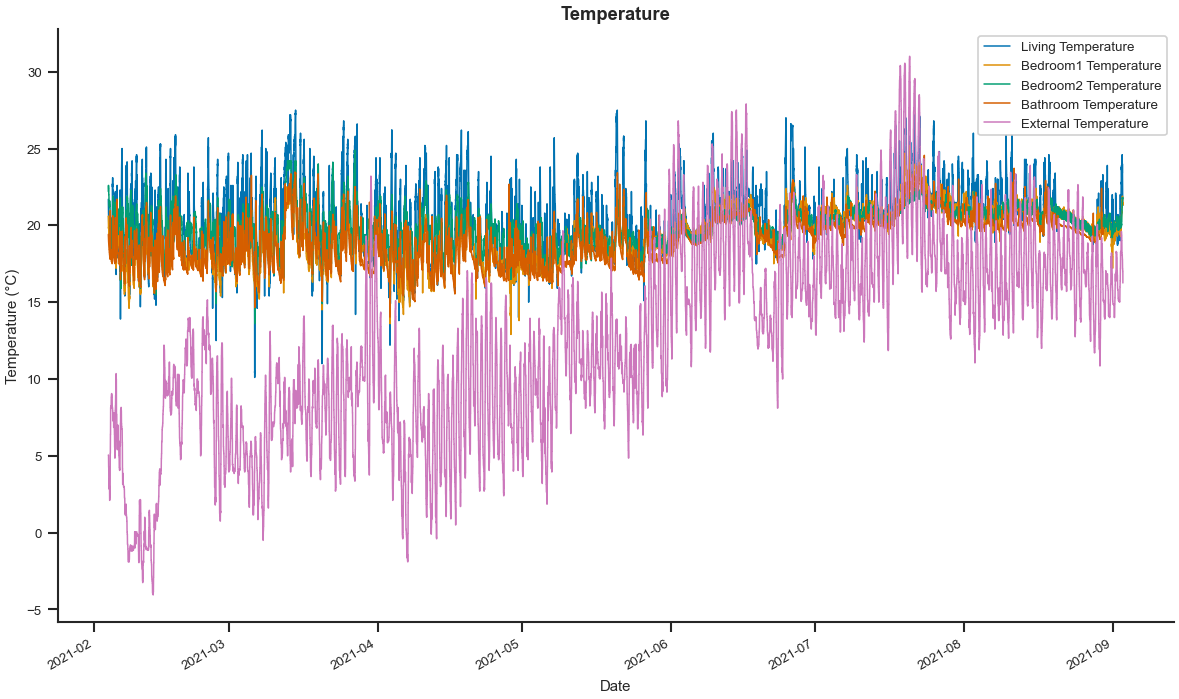

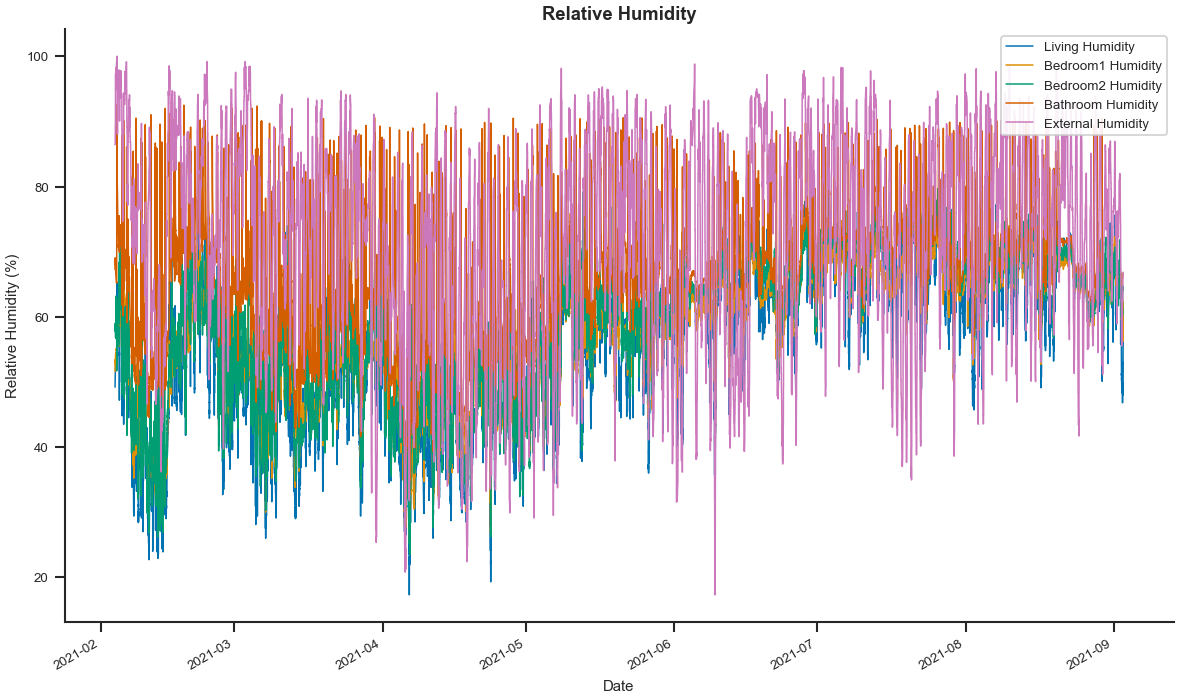

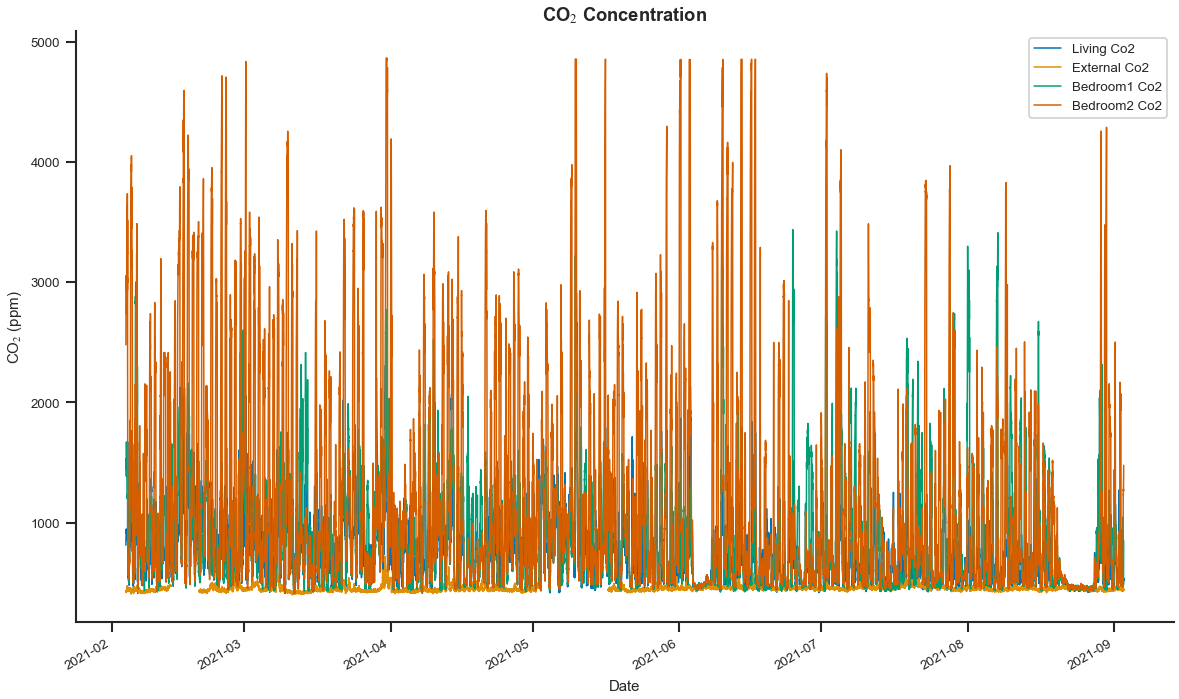

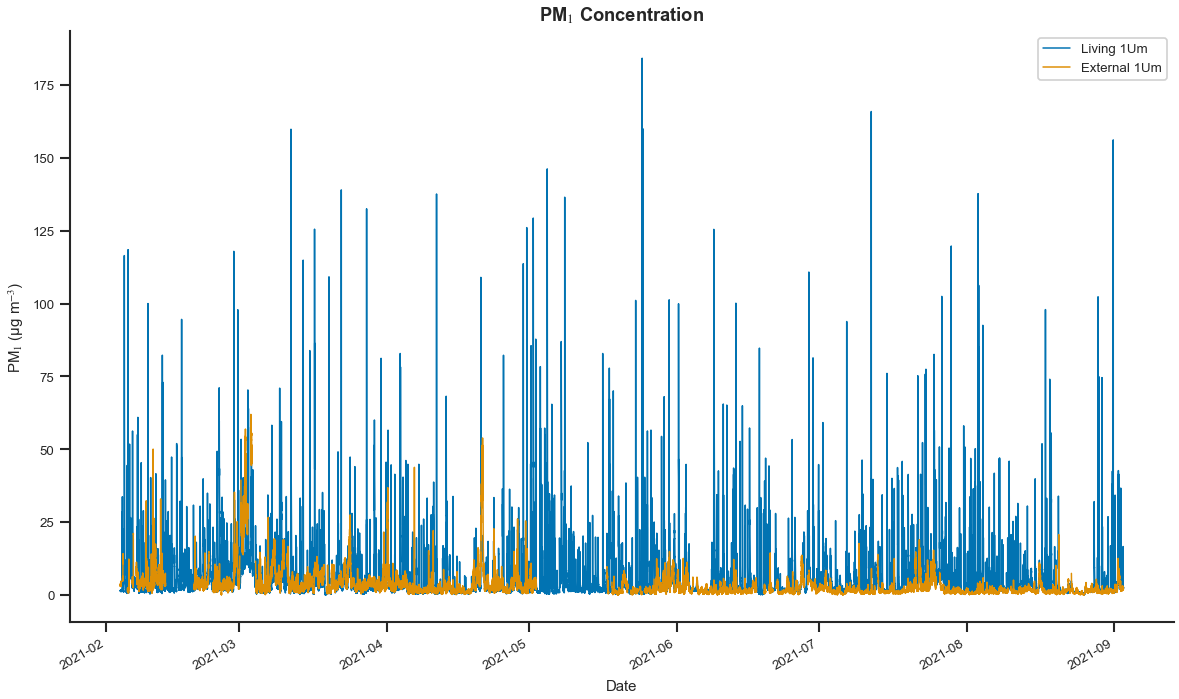

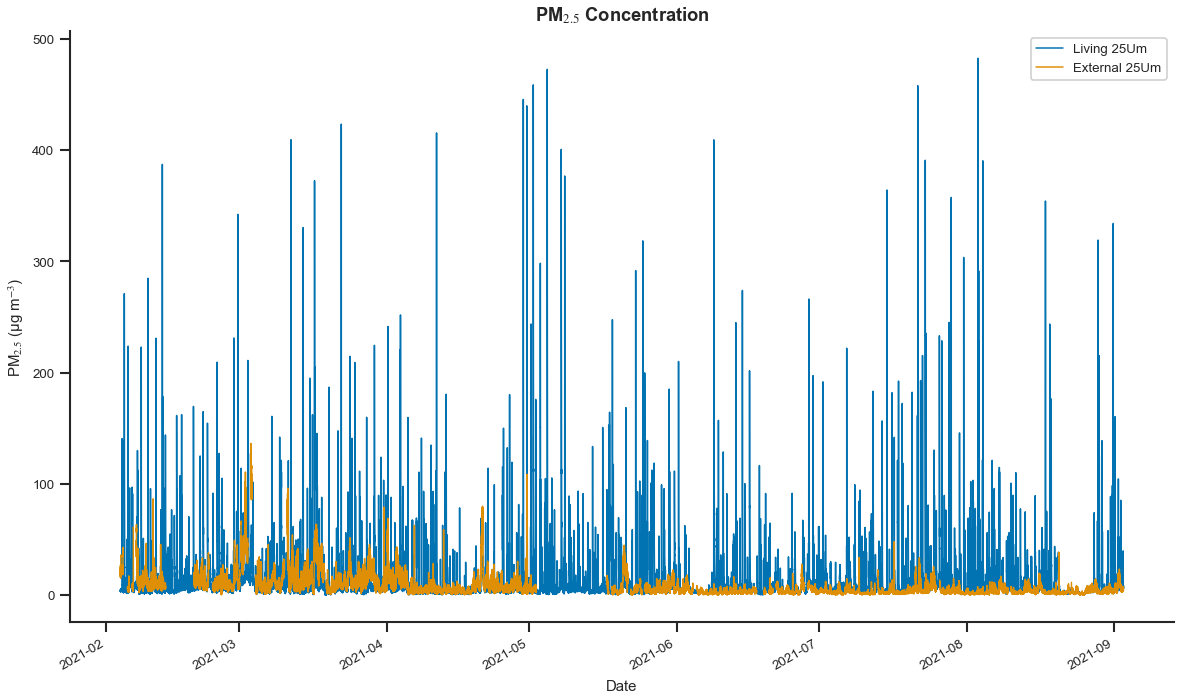

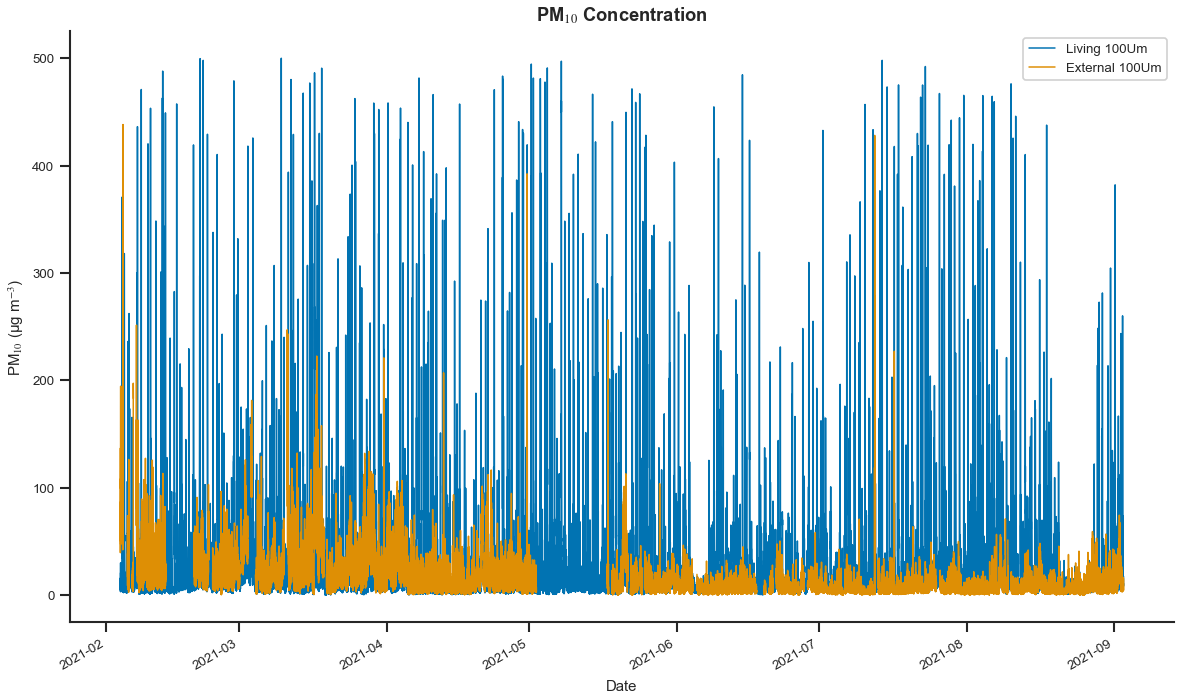

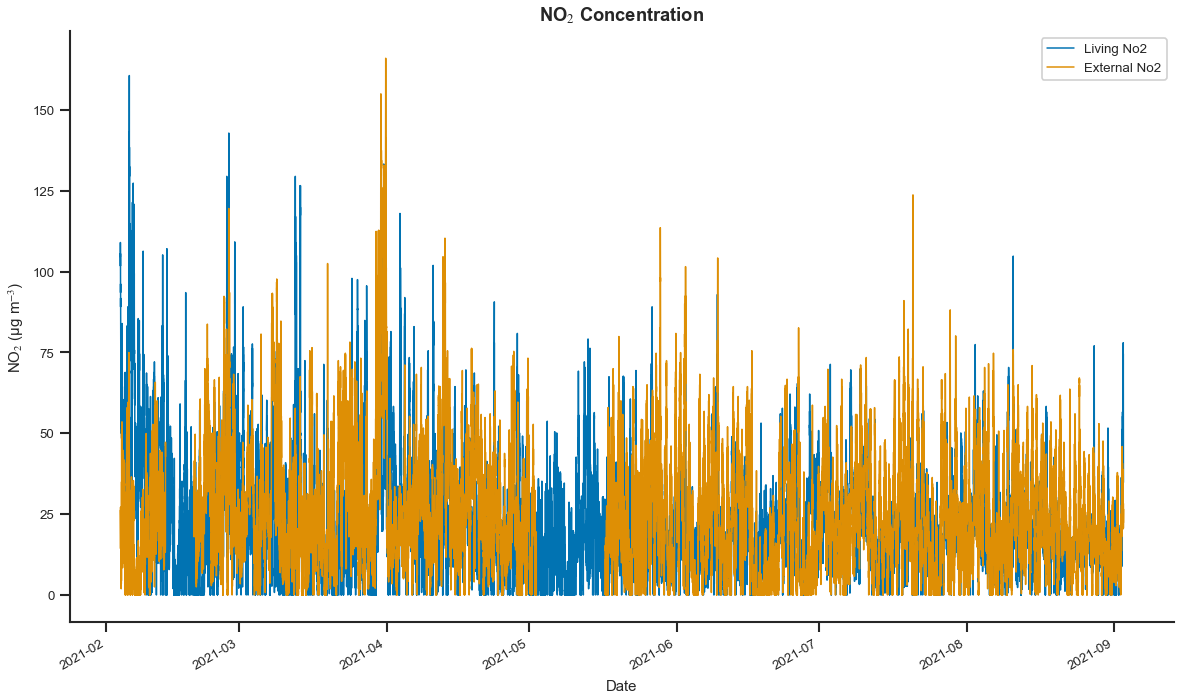

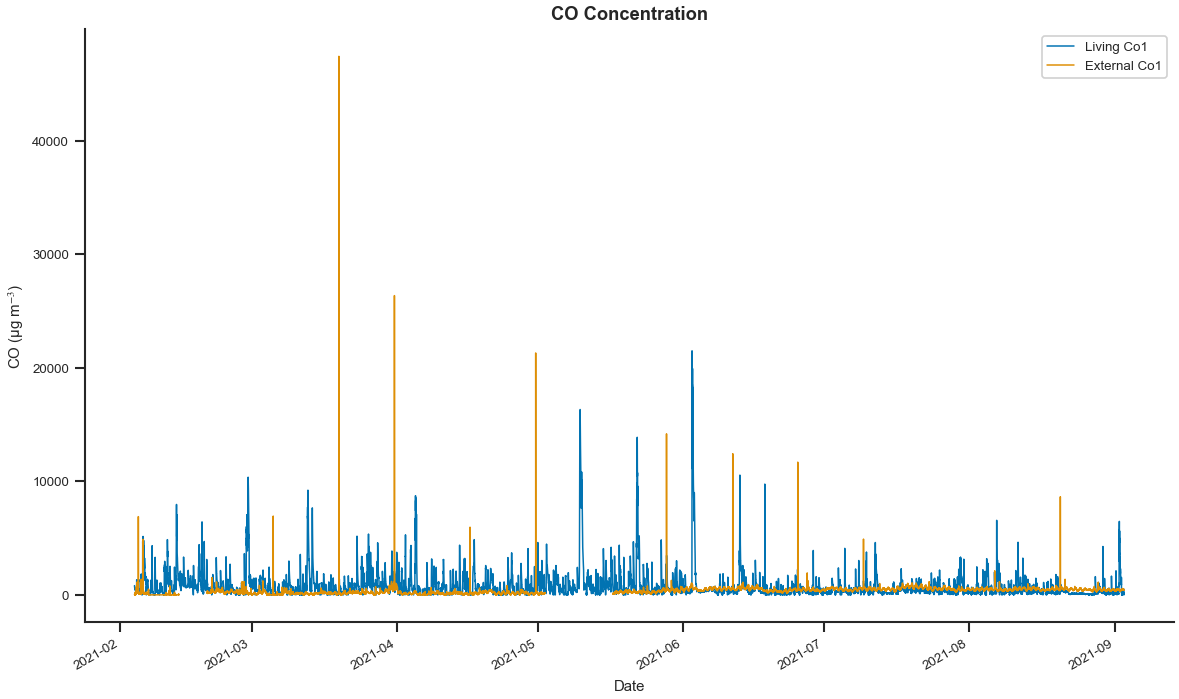

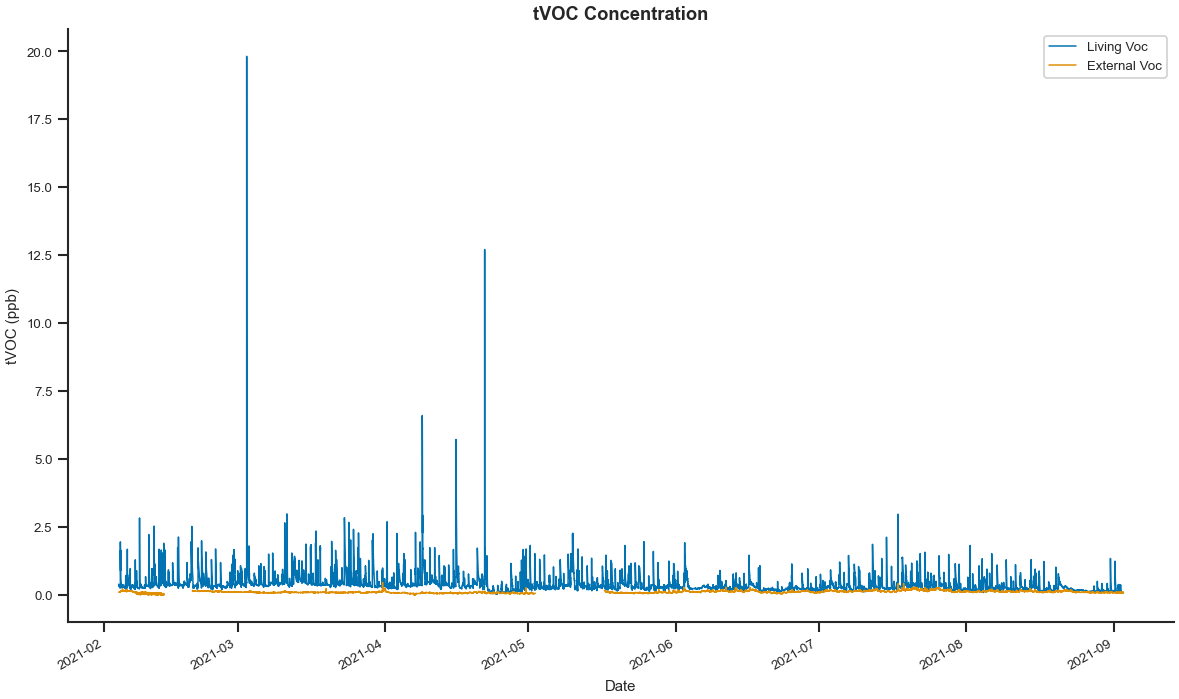

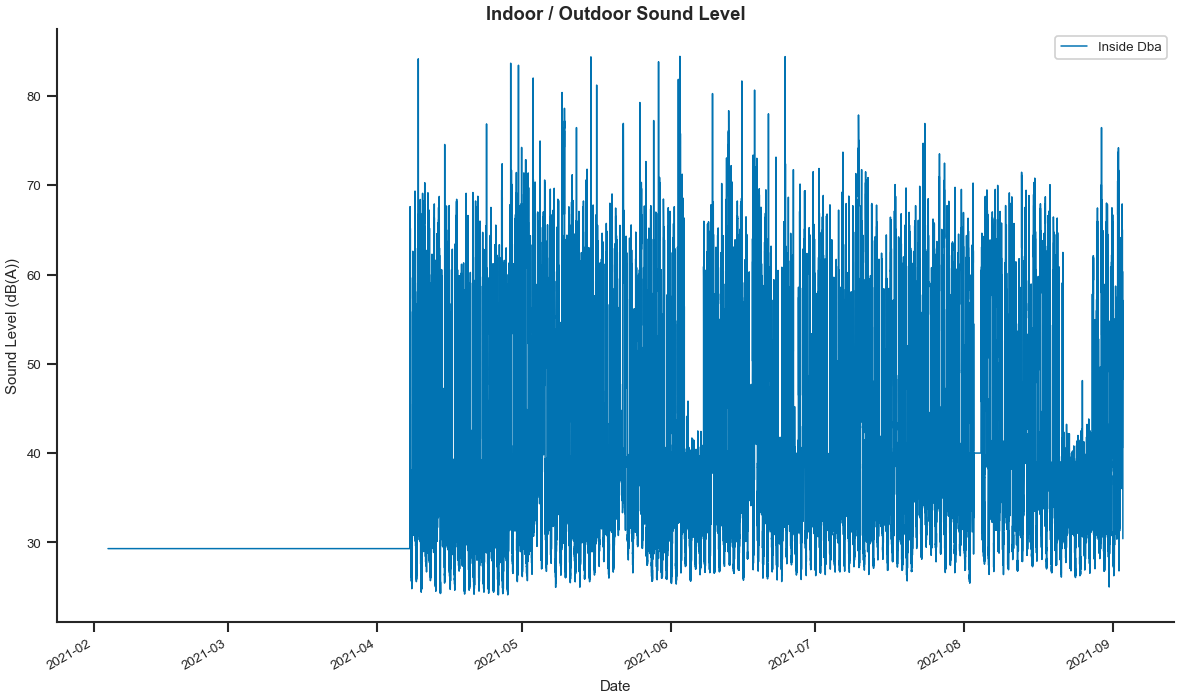

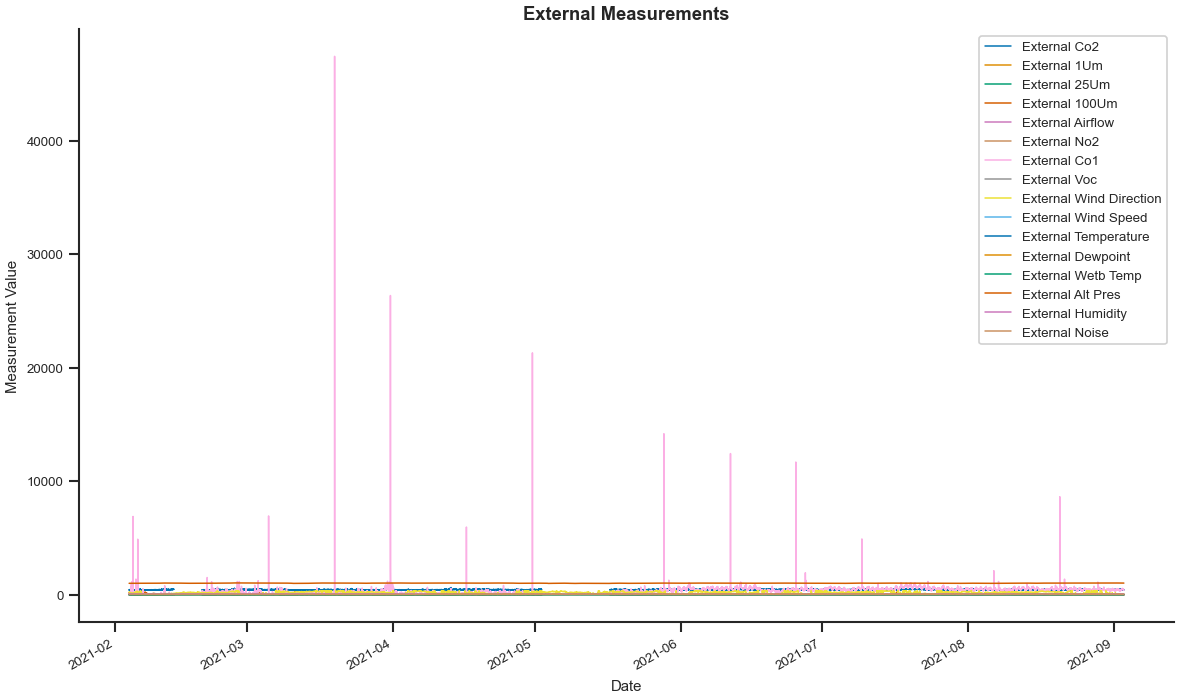

In [17]:
plot_grouped_variables(input_dataframe=p3, input_save=True, save_path="../data/p3_north_west_london_flat/plots/", figsize=(10, 6), dpi=300)

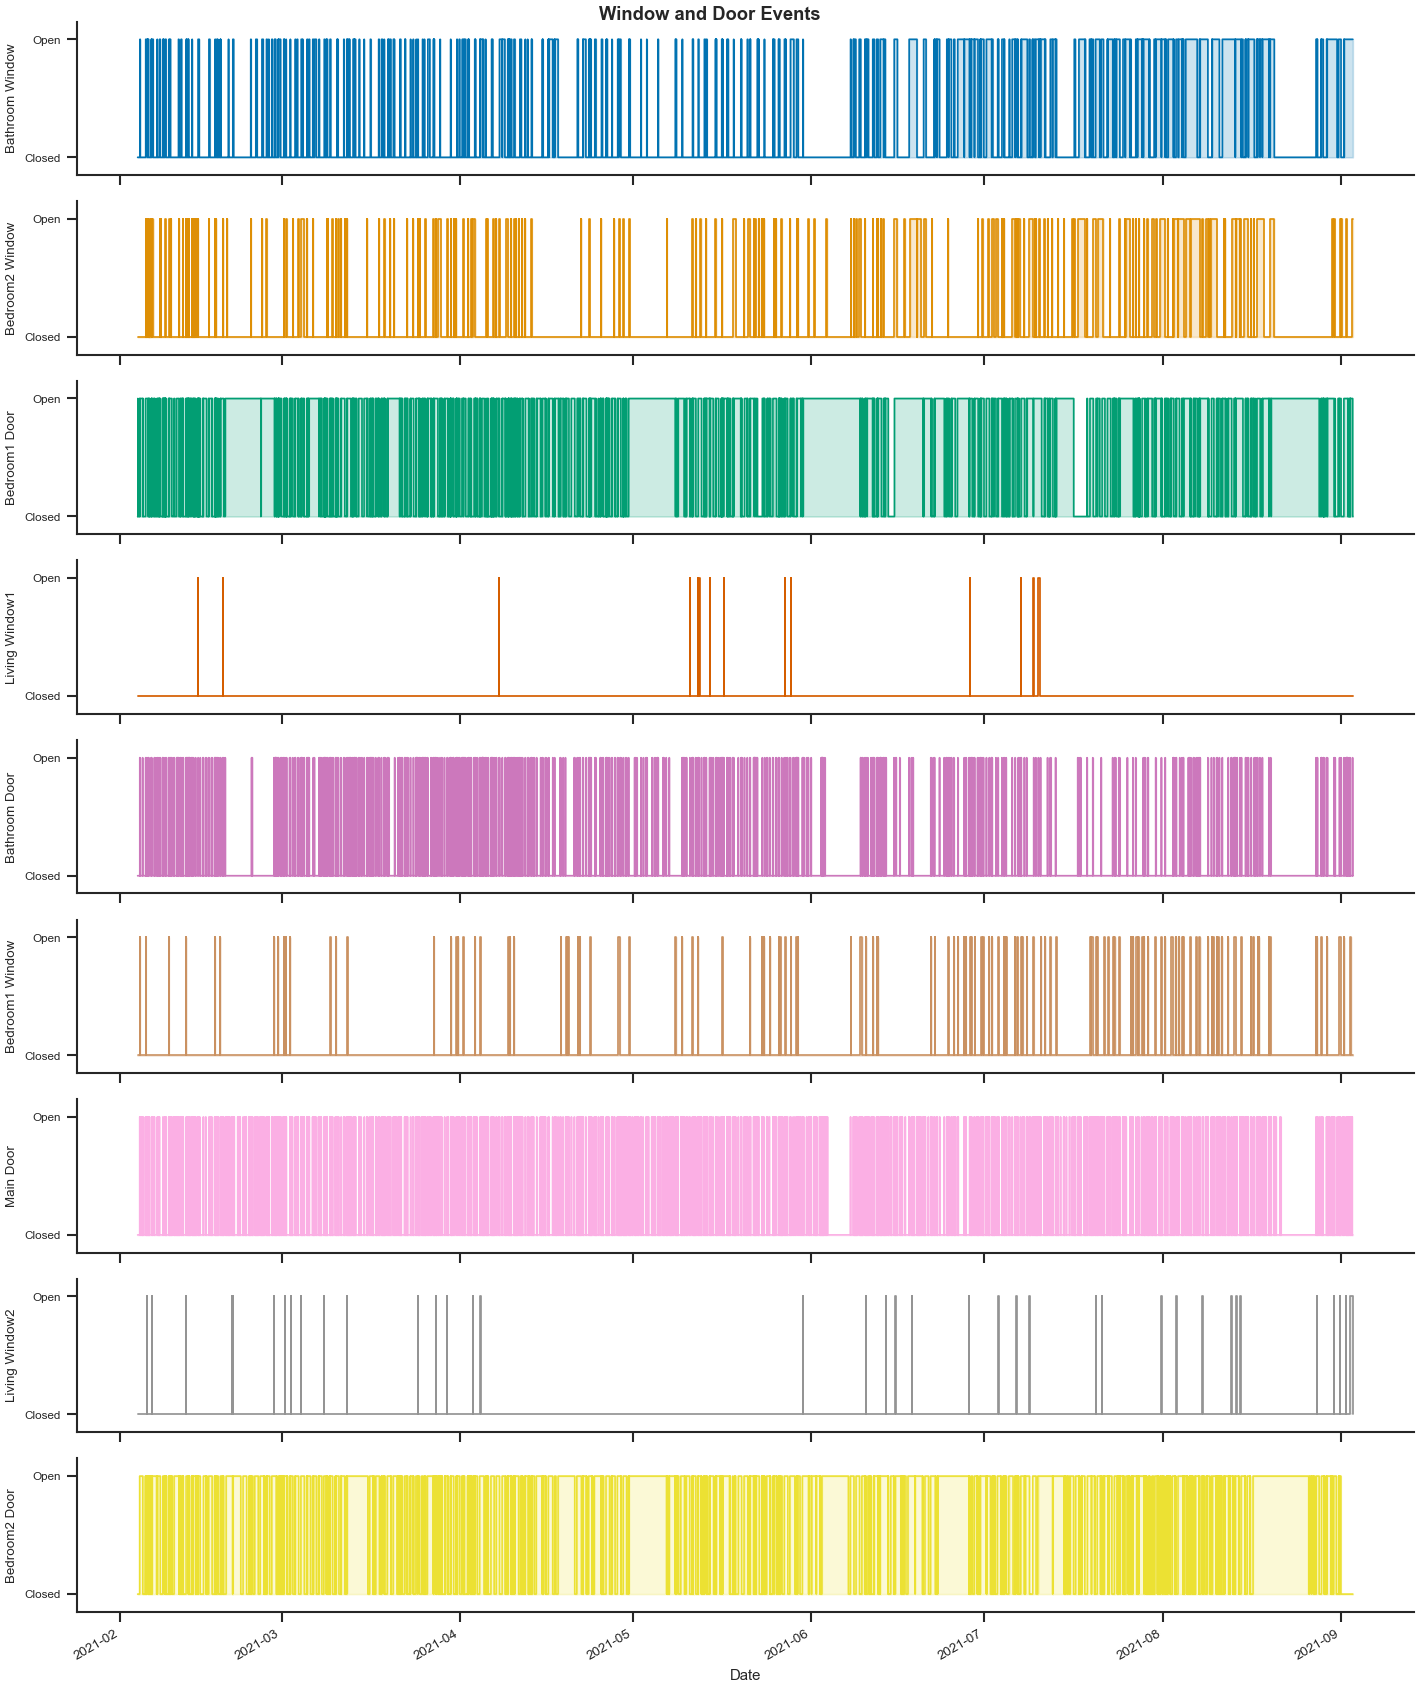

In [18]:
plot_event_timeseries(input_event_dict=p3_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p3_north_west_london_flat/plots/')

## Summary Statistics

In [19]:
p3_continuous_stats, p3_event_stats = summary_statistics(
    input_dataframe=p3,
    input_rooms_and_variables=p3_rooms_and_variables,
    input_event_dict=p3_event_dict,
    input_rooms_and_events=p3_rooms_and_events
)

# Print the number of days of data collected
num_days = (p3.index[-1] - p3.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  bedroom1_temperature: n=60769, n_missing=0, mean=19.381, median=19.4
  bedroom1_humidity: n=60769, n_missing=0, mean=57.391, median=59.0
  bedroom1_co2: n=60769, n_missing=0, mean=877.4, median=713.256
  bathroom_temperature: n=59601, n_missing=1168, mean=18.975, median=19.08
  bathroom_humidity: n=59601, n_missing=1168, mean=64.982, median=66.152
  bathroom_light: n=59601, n_missing=1168, mean=6.423, median=3.9
  living_temperature: n=60769, n_missing=0, mean=20.297, median=20.4
  living_humidity: n=60769, n_missing=0, mean=55.682, median=57.7
  living_co2: n=60769, n_missing=0, mean=720.55, median=655.131
  living_1um: n=60769, n_missing=0, mean=5.109, median=2.62
  living_25um: n=60769, n_missing=0, mean=10.564, median=5.12
  living_100um: n=60769, n_missing=0, mean=21.358, median=8.72
  living_airflow: n=60769, n_missing=0, mean=4.465, median=4.44
  living_no2: n=60769, n_missing=0, mean=20.72, median=17.212
  liv

## Save outputs

In [20]:
save_participant_outputs(
    n=3,
    df=p3,
    event_dict=p3_event_dict,
    rooms_and_variables=p3_rooms_and_variables,
    rooms_and_events=p3_rooms_and_events,
    rooms_list=p3_rooms_list,
    continuous_stats=p3_continuous_stats,
    event_stats=p3_event_stats,
    data_dir='../data/p3_north_west_london_flat')

p3 outputs saved to ../data/p3_north_west_london_flat/data_processed/p3_outputs.pkl
